# Belgian Electricity Imbalance Forecasting

**ML6 Workshop — Team SIAL**

This notebook contains the core forecasting pipeline developed during the ML6
Imbalance Forecasting Workshop.

The objective is to forecast the final Belgian quarter-hour System Imbalance
(SI) from information that would genuinely be available at prediction time.

The implementation focuses on:

- strict publication-delay handling to prevent data leakage;
- minute-level and quarter-hour feature engineering;
- persistence benchmarking;
- XGBoost and LightGBM models;
- one model per minute within the quarter hour;
- volatility-aware sample reweighting;
- hyperparameter tuning and ensembling;
- a two-stage architecture for extreme imbalance events;
- SHAP-based model interpretation.

> **Data availability:** the workshop datasets are not redistributed in this
> portfolio. The notebook expects the original parquet files in a local
> `data/` directory.


## Forecasting setup

Belgian electricity imbalance is settled in 15-minute periods, while
information arrives continuously within each quarter hour.

The modelling task therefore changes as the quarter hour progresses: at
minute 0 very little intra-quarter information is available, while at minute
14 the model has observed almost the entire period.

To reflect this changing information set, the final pipeline trains separate
models for each minute of the quarter hour.


## Configuration

In [ ]:
from pathlib import Path
from typing import Dict, Union, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


In [ ]:
# Publication delays (minutes) — all features must be shifted by these values
# to simulate real-time availability at prediction time.
# Source: Elia Open Data platform documentation.
DELAY_MIN = 2   # SI, ACE, imbalance prices (1-min datasets)
DELAY_QH  = 2   # QH-level datasets (in number of QHs = 30 min)
DELAY_BAL = 3   # Balancing volumes and prices (1-min datasets)

##Exploratory Data Analysis

###1. Loading Data

In [ ]:
# The original ML6 workshop datasets are not redistributed in this portfolio.
# Place the workshop parquet files inside a local `data/` directory.

extract_path = Path("data")

if not extract_path.exists():
    raise FileNotFoundError(
        "Missing `data/` directory. Add the original ML6 workshop parquet "
        "files locally before running this notebook."
    )


The expected input consists of the original ML6 parquet datasets. The helper
below loads every parquet file in `data/` into a dictionary keyed by filename.

The modelling pipeline uses real-time imbalance and ACE signals, renewable
generation forecasts, load forecasts, balancing volumes and balancing prices.


In [ ]:
def load_parquet_folder_as_dict(
    folder: Union[str, Path],
    pattern: str = "*.parquet",
    index_col: Optional[str] = None,
    to_datetime_index: bool = True,
) -> Dict[str, pd.DataFrame]:
    """
    Load all parquet files in `folder` into a dict:
      key   = filename without .parquet
      value = pandas DataFrame

    Args:
        folder: Folder containing parquet files (e.g. "data")
        pattern: Glob pattern (default "*.parquet")
        index_col: If provided, set this column as index after reading.
        to_datetime_index: If True, attempt to convert index to DatetimeIndex.
        sort_index: If True, sort the dataframe by index.

    Returns:
        dict[str, pd.DataFrame]
    """
    folder = Path(folder)
    files = sorted(folder.glob(pattern))

    dfs: Dict[str, pd.DataFrame] = {}
    for fp in files:
        key = fp.stem  # filename without extension
        df = pd.read_parquet(fp)

        if "reference_datetime" in df.columns:
            df = df.set_index("reference_datetime")
        elif "quarterhour" in df.columns:
            df = df.set_index("quarterhour")

        if to_datetime_index and not isinstance(df.index, pd.DatetimeIndex):
            # Try to convert index to datetime if it looks like timestamps
            try:
                df.index = pd.to_datetime(df.index)
            except Exception:
                pass

        dfs[key] = df

    return dfs


df_dict = load_parquet_folder_as_dict("data")


##Baseline Modeling

In [ ]:
#df_1min: one row per minute, containing the real-time
#SI and ACE signals that directly reflect the grid's instantaneous state.
df_1min = df_dict["df_hist_1_min_imbalance_prices"][
    ["systemimbalance", "ace"]
].copy().ffill()

#Load QH forecast data (future covariates)
#Solar, wind and load forecasts are published by Elia before the QH starts.
#We use mostrecentforecast (not measured) — using measured would be leakage.
#No delay needed: these are future covariates.
df_solar = df_dict["df_hist_15_min_solar_power_generation"][
    ["mostrecentforecast"]
].rename(columns={"mostrecentforecast": "solar_forecast"}).ffill()

df_wind = df_dict["df_hist_15_min_wind_power_generation"][
    ["mostrecentforecast"]
].rename(columns={"mostrecentforecast": "wind_forecast"}).ffill()

df_load = df_dict["df_hist_15_min_load_forecast"][
    ["mostrecentforecast"]
].rename(columns={"mostrecentforecast": "load_forecast"}).ffill()

#Target: final QH system imbalance
#The target is the QH-level SI average used by Elia for imbalance settlement.
#It exists only at QH resolution — it is the mean of all 15 minutely values.
df_target = df_dict["df_hist_15_min_imbalance_prices"][
    ["systemimbalance"]
].rename(columns={"systemimbalance": "target_si_qh"}).ffill()

#Build minutely dataframe
#We start from df_1min and expand all QH data to minutely
#resolution using forward fill: every minute inherits the QH-level value.
df = df_1min.copy()

minute_index = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq="1min"
)

def upsample_qh_to_min(df_qh: pd.DataFrame, minute_index) -> pd.DataFrame:
    return df_qh.reindex(minute_index, method="ffill")

df        = df.reindex(minute_index, method="ffill")
solar_min = upsample_qh_to_min(df_solar,  minute_index)
wind_min  = upsample_qh_to_min(df_wind,   minute_index)
load_min  = upsample_qh_to_min(df_load,   minute_index)
target_min= upsample_qh_to_min(df_target, minute_index)

df = df.join(solar_min).join(wind_min).join(load_min).join(target_min)

#Time features

import holidays
df["minute_of_qh"]    = df.index.minute % 15
df["hour"]            = df.index.hour
df["dayofweek"]       = df.index.dayofweek
df["month"]           = df.index.month
df["is_weekend"]      = (df["dayofweek"] >= 5).astype(int)
minutes_in_day        = df.index.hour * 60 + df.index.minute
df["time_of_day_sin"] = np.sin(2 * np.pi * minutes_in_day / (24 * 60))
years                 = df.index.year.unique()
holiday_dates_set     = set(holidays.BE(years=years).keys())
df["is_holiday"]      = np.isin(df.index.date, list(holiday_dates_set)).astype(np.int8)

#SI features with publication delay
#All real-time signals are shifted by DELAY_MIN (2 min) to reflect
#what is actually available at prediction time in a live system.
df["si_delayed"]  = df["systemimbalance"].shift(DELAY_MIN)

#Cumulative SI: expanding mean within each QH.
#At minute k it is already a partial estimate of the final QH target.
df["cumulative_si"] = (
    df.groupby(df.index.floor("15min"))["systemimbalance"]
    .transform(lambda x: x.expanding().mean())
)
df["cumulative_si_delayed"] = df["cumulative_si"].shift(DELAY_MIN)

#SI derivative: captures direction and speed of system evolution.
df["si_trend"] = df["si_delayed"] - df["systemimbalance"].shift(DELAY_MIN + 2)

#Rolling means: capture the recent regime of the system.
#Short windows (2-3 min) are more reactive to sudden changes.
#Longer windows (5-10 min) capture persistent trends.
df["si_roll_mean_2"]  = df["systemimbalance"].shift(DELAY_MIN).rolling(2).mean()
df["si_roll_mean_3"]  = df["systemimbalance"].shift(DELAY_MIN).rolling(3).mean()
df["si_roll_mean_5"]  = df["systemimbalance"].shift(DELAY_MIN).rolling(5).mean()
df["si_roll_mean_10"] = df["systemimbalance"].shift(DELAY_MIN).rolling(10).mean()

#Deeper lags: historical memory beyond the 2-minute delay.
df["si_lag_5"] = df["systemimbalance"].shift(5)

#Balancing volumes and prices (past covariates)
#All balancing signals are shifted by DELAY_BAL (3 min).
df_bal_vol = df_dict["df_hist_1_min_balancing_volumes"][
    ["afrrvolumeup", "afrrvolumedown",
     "igccvolumeup", "igccvolumedown",
     "mfrrsaup", "mfrrdadown"]
].copy().ffill()

df_bal_price = df_dict["df_hist_1_min_balancing_prices"][
    ["marginalincrementalprice", "marginaldecrementalprice",
     "r2priceup", "r2pricedown"]
].copy().ffill()

df_bal_vol["net_balancing_volume"] = (
    df_bal_vol["afrrvolumeup"] - df_bal_vol["afrrvolumedown"]
)
df_bal_price["price_spread"] = (
    df_bal_price["marginalincrementalprice"] -
    df_bal_price["marginaldecrementalprice"]
)

bal_vol_cols   = ["afrrvolumeup", "afrrvolumedown", "net_balancing_volume",
                  "mfrrsaup", "mfrrdadown"]
bal_price_cols = ["r2priceup", "r2pricedown", "price_spread"]

for col in bal_vol_cols:
    df_bal_vol[f"{col}_delayed"] = df_bal_vol[col].shift(DELAY_BAL)
for col in bal_price_cols:
    df_bal_price[f"{col}_delayed"] = df_bal_price[col].shift(DELAY_BAL)

bal_vol_min   = upsample_qh_to_min(
    df_bal_vol[[f"{c}_delayed" for c in bal_vol_cols]], minute_index)
bal_price_min = upsample_qh_to_min(
    df_bal_price[[f"{c}_delayed" for c in bal_price_cols]], minute_index)

df = df.join(bal_vol_min).join(bal_price_min)

#Forecast deviation features: difference between delayed SI and forecast.
#Captures real-time forecast errors that drive system imbalance.
#Using si_delayed (not raw systemimbalance) to respect publication delay.
df["solar_error"] = df["si_delayed"] - df["solar_forecast"]
df["wind_error"]  = df["si_delayed"] - df["wind_forecast"]

#Interaction feature: minute position × cumulative SI.
#Encodes domain knowledge: cumulative_si_delayed becomes increasingly
#predictive of the final QH target as the quarter-hour progresses.
#At minute 0 this is near zero; at minute 14 it closely tracks the target.
df["min_x_cumsi"] = df["minute_of_qh"] * df["cumulative_si_delayed"]

#QH-level lag features
#Extreme events tend to persist across consecutive QHs — if the system
#was severely imbalanced in the previous QH, it is more likely to remain
#so in the current one. These features give the model memory at QH level,
#beyond the minute-level SI signals already available.

df_qh_stats = df.groupby(df.index.floor("15min"))["systemimbalance"].agg([
    "mean", "std", "max", "min"
]).rename(columns={
    "mean": "prev_qh_si_mean",
    "std":  "prev_qh_si_std",
    "max":  "prev_qh_si_max",
    "min":  "prev_qh_si_min"
})

#Shift by 1 QH to avoid leakage — we can only see the previous QH,
#not the current one being predicted.
df_qh_stats = df_qh_stats.shift(1)

#Upsample to minutely resolution and join
df_qh_stats_min = upsample_qh_to_min(df_qh_stats, minute_index)
df = df.join(df_qh_stats_min)

df = df.dropna()

print(f"Final dataframe shape: {df.shape}")
print(f"Date range: {df.index.min()} → {df.index.max()}")

Final dataframe shape: (937365, 37)
Date range: 2024-05-22 00:15:00+00:00 → 2026-03-03 22:59:00+00:00


### Create train/val/test split

In [ ]:
#TRAIN / VAL / TEST SPLIT
#Test set: February 2026 → March 2026
#Validation set: November 2025 → January 2026.
#Training set: everything before November 2025.

TARGET_COL = "target_si_qh"

TEST_START = "2026-02-01"
VAL_START  = "2025-11-01"

df_train = df[df.index < VAL_START]
df_val   = df[(df.index >= VAL_START) & (df.index < TEST_START)]
df_test  = df[df.index >= TEST_START]

y_train = df_train[TARGET_COL]
y_val   = df_val[TARGET_COL]
y_test  = df_test[TARGET_COL]

print(f"Train: {df_train.index.min()} → {df_train.index.max()} | {len(df_train):,} rows")
print(f"Val:   {df_val.index.min()} → {df_val.index.max()} | {len(df_val):,} rows")
print(f"Test:  {df_test.index.min()} → {df_test.index.max()} | {len(df_test):,} rows")

Train: 2024-05-22 00:15:00+00:00 → 2025-10-31 23:59:00+00:00 | 760,305 rows
Val:   2025-11-01 00:00:00+00:00 → 2026-01-31 23:59:00+00:00 | 132,480 rows
Test:  2026-02-01 00:00:00+00:00 → 2026-03-03 22:59:00+00:00 | 44,580 rows


In [ ]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((np.array(y_true) - np.array(y_pred)) ** 2))

In [ ]:
def rmse_high(y_true, y_pred, threshold=300):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = np.abs(y_true) > threshold
    if mask.sum() == 0:
        return np.nan
    return np.sqrt(np.mean((y_true[mask] - y_pred[mask]) ** 2))

def weighted_rmse(y_true, y_pred, threshold=300):
    return 0.5 * rmse(y_true, y_pred) + 0.5 * rmse_high(y_true, y_pred, threshold)

def evaluate(name, y_true, y_pred):
    r_total = rmse(y_true, y_pred)
    r_high  = rmse_high(y_true, y_pred)
    r_w     = weighted_rmse(y_true, y_pred)
    print(f"\n{name}")
    print(f"  RMSE total:    {r_total:.2f} MW")
    print(f"  RMSE high:     {r_high:.2f} MW")
    print(f"  Weighted RMSE: {r_w:.2f} MW")
    return r_total, r_high, r_w

### Persistence Model

In [ ]:
#FEATURE_COLS and TARGET_COL

FEATURE_COLS = ["si_delayed", "ace_delayed", "solar_forecast",
                "wind_forecast", "load_forecast",
                "minute_of_qh", "hour", "dayofweek", "month", "is_weekend"]
TARGET_COL = "target_si_qh"


Persistence Model
  Val  RMSE: 81.09 MW
  Test RMSE: 78.24 MW


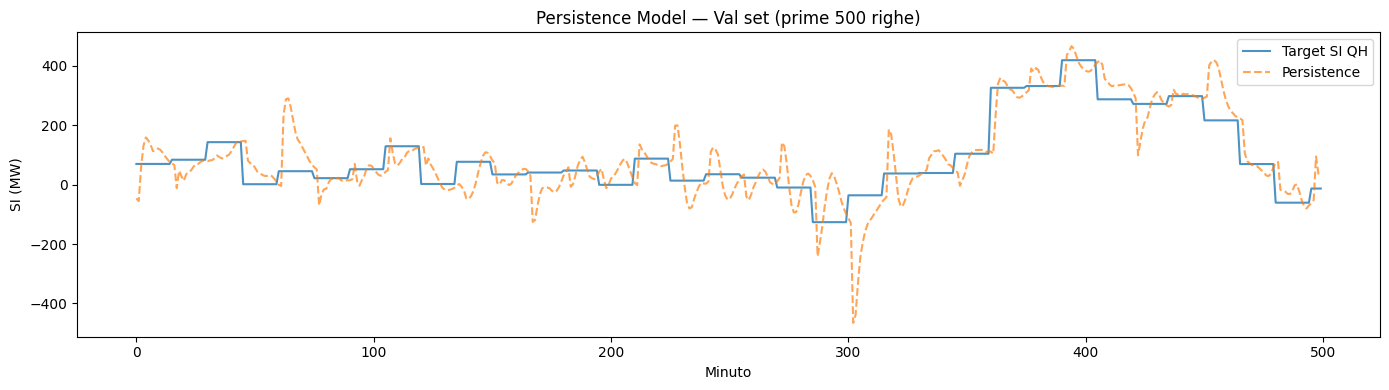

In [ ]:
#The persistence model simply predicts si_delayed
#as the forecast for the final QH value.
persistence_val_preds  = df_val["si_delayed"].values
persistence_test_preds = df_test["si_delayed"].values

val_rmse_persistence  = rmse(df_val[TARGET_COL],  persistence_val_preds)
test_rmse_persistence = rmse(df_test[TARGET_COL], persistence_test_preds)

print(f"\nPersistence Model")
print(f"  Val  RMSE: {val_rmse_persistence:.2f} MW")
print(f"  Test RMSE: {test_rmse_persistence:.2f} MW")


#The plot provides a visual sanity check on the val set, showing how closely
#the persistence prediction tracks the actual target over 500 minutes.
plt.figure(figsize=(14, 4))
plt.plot(df_val[TARGET_COL].values[:500],  label="Target SI QH",   alpha=0.8)
plt.plot(persistence_val_preds[:500],       label="Persistence",    alpha=0.7, linestyle="--")
plt.title("Persistence Model — Val set (prime 500 righe)")
plt.xlabel("Minuto")
plt.ylabel("SI (MW)")
plt.legend()
plt.tight_layout()
plt.show()

#XGBoost + LightGBM



In [ ]:
import lightgbm as lgb
import xgboost as xgb
import shap

# Feature selection based on the workshop analysis:
# - SI signals dominate at all minutes;
# - short rolling SI statistics capture the current grid regime;
# - renewable/load forecasts are most valuable early in the quarter hour;
# - balancing signals help discriminate stressed/extreme periods;
# - SHAP analysis is used to inspect feature importance.

FEATURE_COLS_XGB = [
    # Core SI signals
    "si_delayed", "cumulative_si_delayed", "si_trend",
    "si_roll_mean_2", "si_roll_mean_3",
    "si_roll_mean_5", "si_roll_mean_10",
    "si_lag_5",
    # Interaction feature
    "min_x_cumsi",
    # Previous-quarter statistics
    "prev_qh_si_mean", "prev_qh_si_std",
    "prev_qh_si_max", "prev_qh_si_min",
    # Balancing stress signals
    "afrrvolumeup_delayed", "afrrvolumedown_delayed",
    "net_balancing_volume_delayed", "mfrrsaup_delayed",
    "price_spread_delayed",
    # Future covariates available before delivery
    "solar_forecast", "wind_forecast", "load_forecast",
    # Forecast-deviation features
    "solar_error", "wind_error",
    # Time features
    "minute_of_qh", "hour", "month",
    "is_weekend", "is_holiday", "time_of_day_sin",
]


def train_xgb(X_train, y_train, sample_weight=None):
    model = xgb.XGBRegressor(
        objective="reg:squarederror",
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbosity=0,
    )
    model.fit(X_train, y_train, sample_weight=sample_weight)
    return model


def train_lgbm(X_train, y_train, sample_weight=None):
    model = lgb.LGBMRegressor(
        objective="regression",
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )
    model.fit(X_train, y_train, sample_weight=sample_weight)
    return model


def predict_15x(models, df_set, feature_cols):
    preds = np.zeros(len(df_set))
    for minute, model in models.items():
        mask = (df_set["minute_of_qh"] == minute).values
        preds[mask] = model.predict(df_set.loc[mask, feature_cols])
    return preds


# XGBoost — 15 models, one per QH minute.
xgb_models = {}

for minute in range(15):
    mask_train = df_train["minute_of_qh"] == minute
    X_m = df_train.loc[mask_train, FEATURE_COLS_XGB]
    y_m = df_train.loc[mask_train, TARGET_COL]

    xgb_models[minute] = train_xgb(X_m, y_m)
    print(f"XGB minute {minute:2d} trained")

val_preds_xgb = predict_15x(xgb_models, df_val, FEATURE_COLS_XGB)
test_preds_xgb = predict_15x(xgb_models, df_test, FEATURE_COLS_XGB)

evaluate("XGBoost base — val", y_val, val_preds_xgb)
evaluate("XGBoost base — test", y_test, test_preds_xgb)


In [ ]:
 #Best XGBoost config from tuning results
#val=92.53, test=91.90, high=112.47
BEST_XGB_PARAMS = {
    "learning_rate":    0.05,
    "max_depth":        4,
    "min_child_weight": 3,
    "n_estimators":     300,
    "subsample":        0.8,
    "colsample_bytree": 0.7
}

#Retrain best XGBoost with reweighting to get val and test predictions
best_xgb_models = {}
for m in range(15):
    mask_train = df_train["minute_of_qh"] == m
    subset = df_train.loc[mask_train]
    w_m = compute_volatility_weights(
        subset, alpha_si=15.0, alpha_vol=3.0, std_threshold=80
    )
    model = xgb.XGBRegressor(
        objective="reg:squarederror",
        random_state=42, n_jobs=-1, verbosity=0,
        **BEST_XGB_PARAMS
    )
    model.fit(subset[FEATURE_COLS_XGB], subset[TARGET_COL],
              sample_weight=w_m)
    best_xgb_models[m] = model
    print(f"Minute {m:2d} trained")

best_xgb_preds_val  = predict_15x(best_xgb_models, df_val,  FEATURE_COLS_XGB)
best_xgb_preds_test = predict_15x(best_xgb_models, df_test, FEATURE_COLS_XGB)

evaluate("Best XGBoost reweighted — val",  y_val,  best_xgb_preds_val)
evaluate("Best XGBoost reweighted — test", y_test, best_xgb_preds_test)

Minute  0 trained
Minute  1 trained
Minute  2 trained
Minute  3 trained
Minute  4 trained
Minute  5 trained
Minute  6 trained
Minute  7 trained
Minute  8 trained
Minute  9 trained
Minute 10 trained
Minute 11 trained
Minute 12 trained
Minute 13 trained
Minute 14 trained

Best XGBoost reweighted — val
  RMSE total:    72.54 MW
  RMSE high:     111.03 MW
  Weighted RMSE: 91.78 MW

Best XGBoost reweighted — test
  RMSE total:    71.24 MW
  RMSE high:     111.92 MW
  Weighted RMSE: 91.58 MW


(np.float64(71.24430693532193),
 np.float64(111.92368227113033),
 np.float64(91.58399460322613))

In [ ]:
#Results summary
results = []
for name, preds in [
    ("XGBoost base",          test_preds_xgb),
    ("LightGBM base",         test_preds_lgbm),
    ("Ensemble base",         test_preds_ensemble_base),
    ("Best tuned XGBoost",    best_xgb_preds_test),

]:
    results.append({
        "model":         name,
        "rmse_total":    round(rmse(y_test, preds), 2),
        "rmse_high":     round(rmse_high(y_test, preds), 2),
        "weighted_rmse": round(weighted_rmse(y_test, preds), 2),
    })

pd.DataFrame(results).sort_values("weighted_rmse")

,model,rmse_total,rmse_high,weighted_rmse
3,Best tuned XGBoost,71.24,111.92,91.58
2,Ensemble base,62.27,138.70,100.49
1,LightGBM base,62.49,138.88,100.68
0,XGBoost base,62.50,139.98,101.24


In [ ]:
#LightGBM— 15 models, one per QH minute
#LightGBM uses leaf-wise tree growth vs XGBoost's depth-wise approach.
#This difference causes the two models to make errors in different places,
#making them natural ensembling partners.
lgbm_models = {}
for m in range(15):
    mask_train = df_train["minute_of_qh"] == m
    X_m = df_train.loc[mask_train, FEATURE_COLS_XGB]
    y_m = df_train.loc[mask_train, TARGET_COL]
    lgbm_models[m] = train_lgbm(X_m, y_m)
    print(f"LGBM minute {m:2d} trained")

val_preds_lgbm  = predict_15x(lgbm_models, df_val,  FEATURE_COLS_XGB)
test_preds_lgbm = predict_15x(lgbm_models, df_test, FEATURE_COLS_XGB)
evaluate("LightGBM base — val",  y_val,  val_preds_lgbm)
evaluate("LightGBM base — test", y_test, test_preds_lgbm)

#Ensemble base: XGBoost + LightGBM
#Simple average ensemble. Since XGBoost and LightGBM make different
#errors, their average is typically more accurate than either alone.
val_preds_ensemble_base  = 0.5 * val_preds_xgb  + 0.5 * val_preds_lgbm
test_preds_ensemble_base = 0.5 * test_preds_xgb + 0.5 * test_preds_lgbm
evaluate("Ensemble base — val",  y_val,  val_preds_ensemble_base)
evaluate("Ensemble base — test", y_test, test_preds_ensemble_base)

#Reweighting: volatility-based sample weights ─

# We assign higher weights to:
#samples where |target SI| > 300 MW (magnitude weight)
#samples where recent SI volatility is high (volatility weight)
#Diagnosis showed mfrrsaup_delayed has 8x ratio during extreme events,
#confirming that these periods are structurally different from normal ones.

def compute_volatility_weights(
    df_subset,
    alpha_si=10.0,
    alpha_vol=3.0,
    si_threshold=300,
    std_threshold=80,
):
    """
    weights the samples

    alpha_si:      weight for samples where |target| > si_threshold
    alpha_vol:     weight for samples where si_roll_std_10 > std_threshold
    std_threshold: rolling std threshold that identifies volatile periods
    """

    y = df_subset[TARGET_COL].values
    #Use si_roll_mean_10 as volatility proxy
    std10 = df_subset["si_roll_mean_10"].values
    w_si = np.where(np.abs(y) > si_threshold, alpha_si, 1.0)
    w_vol = np.where(np.abs(std10) > std_threshold, alpha_vol, 1.0)
    return w_si * w_vol

# Search over configurations — evaluated on val set
configs = [
    (10.0, 3.0, 80),
    (15.0, 3.0, 80),
    (10.0, 5.0, 80),
    (15.0, 5.0, 100),
    (20.0, 3.0, 80),
]

best_val_rmse = np.inf
best_xgb_rw = None
best_lgbm_rw = None
best_config = None

for alpha_si, alpha_vol, std_thr in configs:
    xgb_rw = {}
    lgbm_rw = {}

    for m in range(15):
        mask_train = df_train["minute_of_qh"] == m
        subset = df_train.loc[mask_train]
        X_m = subset[FEATURE_COLS_XGB]
        y_m = subset[TARGET_COL]
        w_m = compute_volatility_weights(
            subset, alpha_si=alpha_si, alpha_vol=alpha_vol, std_threshold=std_thr
        )
        xgb_rw[m] = train_xgb(X_m, y_m, sample_weight=w_m)
        lgbm_rw[m] = train_lgbm(X_m, y_m, sample_weight=w_m)

    val_xgb_rw = predict_15x(xgb_rw, df_val, FEATURE_COLS_XGB)
    val_lgbm_rw = predict_15x(lgbm_rw, df_val, FEATURE_COLS_XGB)
    val_ens_rw = 0.5 * val_xgb_rw + 0.5 * val_lgbm_rw

    test_xgb_rw = predict_15x(xgb_rw, df_test, FEATURE_COLS_XGB)
    test_lgbm_rw = predict_15x(lgbm_rw, df_test, FEATURE_COLS_XGB)
    test_ens_rw = 0.5 * test_xgb_rw + 0.5 * test_lgbm_rw

    r_val = weighted_rmse(y_val, val_ens_rw)
    r_test = weighted_rmse(y_test, test_ens_rw)
    r_high = rmse_high(y_test, test_ens_rw)

    print(
        f"si={alpha_si:.0f} vol={alpha_vol:.0f} std>{std_thr} | "
        f"val={r_val:.2f} | test={r_test:.2f} | high={r_high:.2f}"
    )

    if r_val < best_val_rmse:
        best_val_rmse = r_val
        best_xgb_rw = xgb_rw
        best_lgbm_rw = lgbm_rw
        best_config = (alpha_si, alpha_vol, std_thr)

print(f"\nBest config: si={best_config[0]}, vol={best_config[1]}, std>{best_config[2]}")

#Ensemble: blend base + reweighted

print("\nSearching optimal blend weight...")
best_blend_val = np.inf
best_blend_w = None
best_blend_test = None

for w_rw in np.arange(0.1, 1.0, 0.1):
    w_base = 1 - w_rw

    val_blend = (
        w_rw
        * (
            0.5 * predict_15x(best_xgb_rw, df_val, FEATURE_COLS_XGB)
            + 0.5 * predict_15x(best_lgbm_rw, df_val, FEATURE_COLS_XGB)
        )
        + w_base * val_preds_ensemble_base
    )
    test_blend = (
        w_rw
        * (
            0.5 * predict_15x(best_xgb_rw, df_test, FEATURE_COLS_XGB)
            + 0.5 * predict_15x(best_lgbm_rw, df_test, FEATURE_COLS_XGB)
        )
        + w_base * test_preds_ensemble_base
    )

    r_val = weighted_rmse(y_val, val_blend)
    r_test = weighted_rmse(y_test, test_blend)
    r_high = rmse_high(y_test, test_blend)
    r_tot = rmse(y_test, test_blend)

    print(
        f"rw={w_rw:.1f} base={w_base:.1f} | "
        f"val={r_val:.2f} | test={r_test:.2f} | "
        f"total={r_tot:.2f} | high={r_high:.2f}"
    )

    if r_val < best_blend_val:
        best_blend_val = r_val
        best_blend_w = w_rw
        best_blend_test = test_blend

print(f"\nBest blend: reweighted={best_blend_w:.1f} base={1-best_blend_w:.1f}")
evaluate("Final ensemble — test", y_test, best_blend_test)

#Results summary
results = []
for name, preds in [
    ("XGBoost base", test_preds_xgb),
    ("LightGBM base", test_preds_lgbm),
    ("Ensemble base", test_preds_ensemble_base),
    ("Final ensemble", best_blend_test),
]:
    results.append(
        {
            "model": name,
            "rmse_total": round(rmse(y_test, preds), 2),
            "rmse_high": round(rmse_high(y_test, preds), 2),
            "weighted_rmse": round(weighted_rmse(y_test, preds), 2),
        }
    )

pd.DataFrame(results).sort_values("weighted_rmse")

LGBM minute  0 trained
LGBM minute  1 trained
LGBM minute  2 trained
LGBM minute  3 trained
LGBM minute  4 trained
LGBM minute  5 trained
LGBM minute  6 trained
LGBM minute  7 trained
LGBM minute  8 trained
LGBM minute  9 trained
LGBM minute 10 trained
LGBM minute 11 trained
LGBM minute 12 trained
LGBM minute 13 trained
LGBM minute 14 trained

LightGBM base — val
  RMSE total:    63.79 MW
  RMSE high:     135.50 MW
  Weighted RMSE: 99.65 MW

LightGBM base — test
  RMSE total:    62.49 MW
  RMSE high:     138.88 MW
  Weighted RMSE: 100.68 MW

Ensemble base — val
  RMSE total:    63.39 MW
  RMSE high:     133.51 MW
  Weighted RMSE: 98.45 MW

Ensemble base — test
  RMSE total:    62.27 MW
  RMSE high:     138.70 MW
  Weighted RMSE: 100.49 MW
si=10 vol=3 std>80 | val=92.54 | test=91.79 | high=117.01
si=15 vol=3 std>80 | val=92.49 | test=92.13 | high=115.49
si=10 vol=5 std>80 | val=92.78 | test=92.28 | high=117.92
si=15 vol=5 std>100 | val=92.69 | test=92.11 | high=115.13
si=20 vol=3 std>80

,model,rmse_total,rmse_high,weighted_rmse
3,Final ensemble,67.56,116.93,92.25
2,Ensemble base,62.27,138.70,100.49
1,LightGBM base,62.49,138.88,100.68
0,XGBoost base,62.50,139.98,101.24


In [ ]:

#SHAP analysis on XGBoost model for minute 0 and minute 14
#We analyse the two most different regimes:
#- Minute 0: model has no intra-QH info, relies on external signals
#- Minute 14: model has almost complete QH history

for minute in [0, 7, 14]:
    model_m = xgb_models[minute]
    mask    = (df_val["minute_of_qh"] == minute).values
    X_m     = df_val.loc[mask, FEATURE_COLS_XGB]

    #Use TreeExplainer
    explainer   = shap.TreeExplainer(model_m)
    shap_values = explainer.shap_values(X_m)

    plt.figure(figsize=(10, 6))
    shap.summary_plot(
        shap_values, X_m,
        plot_type="bar",
        show=False,
        max_display=15
    )
    plt.title(f"SHAP feature importance — minute {minute} of QH")
    plt.tight_layout()
    plt.show()

#Global SHAP across all minutes
sample = df_val.sample(2000, random_state=42)
all_shap = np.zeros((len(sample), len(FEATURE_COLS_XGB)))

for minute in range(15):
    mask = (sample["minute_of_qh"] == minute).values
    if mask.sum() == 0:
        continue
    X_m = sample.loc[mask, FEATURE_COLS_XGB]
    exp = shap.TreeExplainer(xgb_models[minute])
    all_shap[mask] = exp.shap_values(X_m)

plt.figure(figsize=(10, 8))
shap.summary_plot(
    all_shap, sample[FEATURE_COLS_XGB],
    plot_type="dot",
    show=False,
    max_display=20
)
plt.title("Global SHAP summary — all QH minutes")
plt.tight_layout()
plt.show()

In [ ]:
#TWO-STAGE MODEL
#Stage 1: binary classifier — will this QH be extreme (|SI| > 300)?
#Stage 2a: regressor trained only on normal QHs
#Stage 2b: regressor trained only on extreme QHs
#Final prediction: weighted blend based on Stage 1 probability.

#Motivation: extreme events (5.8% of test set) have fundamentally
#different dynamics. A single model averages over both regimes,
#underperforming on both. Separating them allows each regressor
#to specialise.

EXTREME_THRESHOLD = 300

#Stage 1: Classifier
#Target: 1 if |target_si_qh| > 300, else 0
#Trained on the same features as the regressors.
#We use 15 separate classifiers, one per QH minute.

clf_models = {}
for m in range(15):
    mask_train = df_train["minute_of_qh"] == m
    X_m = df_train.loc[mask_train, FEATURE_COLS_XGB]
    y_m = (np.abs(df_train.loc[mask_train, TARGET_COL]) > EXTREME_THRESHOLD).astype(int)

    clf = lgb.LGBMClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
        class_weight="balanced"
    )
    clf.fit(X_m, y_m)
    clf_models[m] = clf
    print(f"Classifier minute {m:2d} trained")

#Check classifier performance on val set
val_proba_extreme = np.zeros(len(df_val))
for m, clf in clf_models.items():
    mask = (df_val["minute_of_qh"] == m).values
    val_proba_extreme[mask] = clf.predict_proba(
        df_val.loc[mask, FEATURE_COLS_XGB]
    )[:, 1]

val_extreme_true = (np.abs(y_val) > EXTREME_THRESHOLD).astype(int)
val_extreme_pred = (val_proba_extreme > 0.5).astype(int)

from sklearn.metrics import classification_report
print("\nClassifier performance on val set:")
print(classification_report(val_extreme_true, val_extreme_pred,
                             target_names=["normal", "extreme"]))

#Stage 2a: Regressor for normal QHs
# Trained only on rows where |target| <= 300
# Uses best XGBoost params found during tuning

reg_normal = {}
for m in range(15):
    mask_train = df_train["minute_of_qh"] == m
    subset = df_train.loc[mask_train]
    normal_mask = np.abs(subset[TARGET_COL]) <= EXTREME_THRESHOLD
    X_m = subset.loc[normal_mask, FEATURE_COLS_XGB]
    y_m = subset.loc[normal_mask, TARGET_COL]
    reg_normal[m] = train_xgb(X_m, y_m)
    print(f"Normal regressor minute {m:2d} trained | {normal_mask.sum()} samples")

#Stage 2b: Regressor for extreme QHs
#Trained only on rows where |target| > 300
#Uses high reweighting since these are already extreme samples

reg_extreme = {}
for m in range(15):
    mask_train = df_train["minute_of_qh"] == m
    subset = df_train.loc[mask_train]
    extreme_mask = np.abs(subset[TARGET_COL]) > EXTREME_THRESHOLD
    X_m = subset.loc[extreme_mask, FEATURE_COLS_XGB]
    y_m = subset.loc[extreme_mask, TARGET_COL]

    if len(X_m) < 10:
        # Too few extreme samples for this minute — fall back to normal model
        reg_extreme[m] = reg_normal[m]
        print(f"Extreme regressor minute {m:2d} — too few samples ({len(X_m)}), using normal model")
    else:
        reg_extreme[m] = train_xgb(X_m, y_m)
        print(f"Extreme regressor minute {m:2d} trained | {extreme_mask.sum()} samples")

#Final prediction: blend based on classifier probability
def predict_two_stage(clf_models, reg_normal, reg_extreme,
                      df_set, feature_cols, threshold=0.5):
    """
    For each row:
    - Get P(extreme) from classifier
    - If P(extreme) >= threshold: use extreme regressor
    - If P(extreme) < threshold: use normal regressor
    - Final = P(extreme) * pred_extreme + (1 - P(extreme)) * pred_normal
    """
    preds_normal  = np.zeros(len(df_set))
    preds_extreme = np.zeros(len(df_set))
    proba_extreme = np.zeros(len(df_set))

    for m in range(15):
        mask = (df_set["minute_of_qh"] == m).values
        X_m  = df_set.loc[mask, feature_cols]

        proba_extreme[mask]  = clf_models[m].predict_proba(X_m)[:, 1]
        preds_normal[mask]   = reg_normal[m].predict(X_m)
        preds_extreme[mask]  = reg_extreme[m].predict(X_m)

    #Soft blend: weighted by classifier probability
    preds_final = (
        proba_extreme * preds_extreme +
        (1 - proba_extreme) * preds_normal
    )
    return preds_final, proba_extreme

val_preds_2stage,  val_proba  = predict_two_stage(
    clf_models, reg_normal, reg_extreme, df_val,  FEATURE_COLS_XGB)
test_preds_2stage, test_proba = predict_two_stage(
    clf_models, reg_normal, reg_extreme, df_test, FEATURE_COLS_XGB)

evaluate("Two-stage model — val",  y_val,  val_preds_2stage)
evaluate("Two-stage model — test", y_test, test_preds_2stage)

#Blend two-stage with best tuned ensemble
print("\nBlending two-stage with best tuned ensemble...")
for w_2stage in np.arange(0.1, 1.0, 0.1):
    blend_val  = w_2stage * val_preds_2stage  + (1-w_2stage) * best_xgb_preds_val
    blend_test = w_2stage * test_preds_2stage + (1-w_2stage) * best_xgb_preds_test
    r_val  = weighted_rmse(y_val,  blend_val)
    r_test = weighted_rmse(y_test, blend_test)
    r_high = rmse_high(y_test, blend_test)
    print(f"2stage={w_2stage:.1f} | val={r_val:.2f} | test={r_test:.2f} | high={r_high:.2f}")

Classifier minute  0 trained
Classifier minute  1 trained
Classifier minute  2 trained
Classifier minute  3 trained
Classifier minute  4 trained
Classifier minute  5 trained
Classifier minute  6 trained
Classifier minute  7 trained
Classifier minute  8 trained
Classifier minute  9 trained
Classifier minute 10 trained
Classifier minute 11 trained
Classifier minute 12 trained
Classifier minute 13 trained
Classifier minute 14 trained

Classifier performance on val set:
              precision    recall  f1-score   support

      normal       0.99      0.92      0.96    124425
     extreme       0.42      0.87      0.57      8055

    accuracy                           0.92    132480
   macro avg       0.71      0.90      0.76    132480
weighted avg       0.96      0.92      0.93    132480

Normal regressor minute  0 trained | 47267 samples
Normal regressor minute  1 trained | 47267 samples
Normal regressor minute  2 trained | 47267 samples
Normal regressor minute  3 trained | 47267 sample

In [ ]:
# Best blend: 50% two-stage + 50% tuned XGBoost ensemble
BEST_BLEND_W = 0.5
best_blend_val  = BEST_BLEND_W * val_preds_2stage  + (1-BEST_BLEND_W) * best_xgb_preds_val
best_blend_test = BEST_BLEND_W * test_preds_2stage + (1-BEST_BLEND_W) * best_xgb_preds_test

evaluate("Best blend (2stage=0.5) — val",  y_val,  best_blend_val)
evaluate("Best blend (2stage=0.5) — test", y_test, best_blend_test)


Best blend (2stage=0.5) — val
  RMSE total:    70.34 MW
  RMSE high:     112.02 MW
  Weighted RMSE: 91.18 MW

Best blend (2stage=0.5) — test
  RMSE total:    68.75 MW
  RMSE high:     111.85 MW
  Weighted RMSE: 90.30 MW


(np.float64(68.75116587623188),
 np.float64(111.84912821616739),
 np.float64(90.30014704619964))

###Hyperparameter Tuning

In [ ]:
import random
from itertools import product

random.seed(42)

#Hyperparameter tuning — XGBoost + LightGBM reweighted
#We tune both models separately with the best reweighting config
#(alpha_si=15, alpha_vol=3, std>80) and then ensemble the best of each.
#Selection criterion: Weighted RMSE on validation set.

param_grid_xgb = {
    "learning_rate":    [0.01, 0.03, 0.05],
    "max_depth":        [4, 5, 6],
    "min_child_weight": [3, 5, 10],
    "n_estimators":     [300, 500],
    "subsample":        [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
}

param_grid_lgbm = {
    "learning_rate":     [0.01, 0.03, 0.05],
    "num_leaves":        [31, 63, 127],
    "min_child_samples": [10, 20, 50],
    "n_estimators":      [300, 500],
    "subsample":         [0.7, 0.8, 1.0],
    "colsample_bytree":  [0.7, 0.8, 1.0],
}

N_SAMPLES = 30  # configs per model

all_xgb  = list(product(*param_grid_xgb.values()))
all_lgbm = list(product(*param_grid_lgbm.values()))
keys_xgb  = list(param_grid_xgb.keys())
keys_lgbm = list(param_grid_lgbm.keys())

sampled_xgb  = random.sample(all_xgb,  N_SAMPLES)
sampled_lgbm = random.sample(all_lgbm, N_SAMPLES)

print(f"XGBoost search space: {len(all_xgb)} combinations, sampling {N_SAMPLES}")
print(f"LightGBM search space: {len(all_lgbm)} combinations, sampling {N_SAMPLES}")
print(f"Total models to train: {N_SAMPLES * 2 * 15}\n")

#XGBoost tuning
print("=" * 60)
print("TUNING XGBOOST")
print("=" * 60)

best_xgb_val   = np.inf
best_xgb_preds_val  = None
best_xgb_preds_test = None
best_xgb_params = None
best_xgb_models = None
xgb_tuning_results = []

for i, combo in enumerate(sampled_xgb):
    params = dict(zip(keys_xgb, combo))

    xgb_tuned = {}
    for m in range(15):
        mask_train = df_train["minute_of_qh"] == m
        subset = df_train.loc[mask_train]
        w_m = compute_volatility_weights(
            subset, alpha_si=15.0, alpha_vol=3.0, std_threshold=80
        )
        model = xgb.XGBRegressor(
            objective="reg:squarederror",
            random_state=42, n_jobs=-1, verbosity=0,
            **params
        )
        model.fit(subset[FEATURE_COLS_XGB], subset[TARGET_COL],
                  sample_weight=w_m)
        xgb_tuned[m] = model

    val_p  = predict_15x(xgb_tuned, df_val,  FEATURE_COLS_XGB)
    test_p = predict_15x(xgb_tuned, df_test, FEATURE_COLS_XGB)

    r_val  = weighted_rmse(y_val,  val_p)
    r_test = weighted_rmse(y_test, test_p)
    r_high = rmse_high(y_test, test_p)

    xgb_tuning_results.append({
        **params,
        "val_weighted_rmse":  round(r_val, 2),
        "test_weighted_rmse": round(r_test, 2),
        "test_rmse_high":     round(r_high, 2),
    })

    print(f"XGB [{i+1:2d}/{N_SAMPLES}] val={r_val:.2f} test={r_test:.2f} "
          f"high={r_high:.2f} | {params}")

    if r_val < best_xgb_val:
        best_xgb_val        = r_val
        best_xgb_preds_val  = val_p
        best_xgb_preds_test = test_p
        best_xgb_params     = params
        best_xgb_models     = xgb_tuned

print(f"\nBest XGBoost config: {best_xgb_params}")
evaluate("Best tuned XGBoost — test", y_test, best_xgb_preds_test)

#LightGBM tuning
print("\n" + "=" * 60)
print("TUNING LIGHTGBM")
print("=" * 60)

best_lgbm_val   = np.inf
best_lgbm_preds_val  = None
best_lgbm_preds_test = None
best_lgbm_params = None
best_lgbm_models = None
lgbm_tuning_results = []

for i, combo in enumerate(sampled_lgbm):
    params = dict(zip(keys_lgbm, combo))

    lgbm_tuned = {}
    for m in range(15):
        mask_train = df_train["minute_of_qh"] == m
        subset = df_train.loc[mask_train]
        w_m = compute_volatility_weights(
            subset, alpha_si=15.0, alpha_vol=3.0, std_threshold=80
        )
        model = lgb.LGBMRegressor(
            objective="regression",
            random_state=42, n_jobs=-1, verbose=-1,
            **params
        )
        model.fit(subset[FEATURE_COLS_XGB], subset[TARGET_COL],
                  sample_weight=w_m)
        lgbm_tuned[m] = model

    val_p  = predict_15x(lgbm_tuned, df_val,  FEATURE_COLS_XGB)
    test_p = predict_15x(lgbm_tuned, df_test, FEATURE_COLS_XGB)

    r_val  = weighted_rmse(y_val,  val_p)
    r_test = weighted_rmse(y_test, test_p)
    r_high = rmse_high(y_test, test_p)

    lgbm_tuning_results.append({
        **params,
        "val_weighted_rmse":  round(r_val, 2),
        "test_weighted_rmse": round(r_test, 2),
        "test_rmse_high":     round(r_high, 2),
    })

    print(f"LGBM [{i+1:2d}/{N_SAMPLES}] val={r_val:.2f} test={r_test:.2f} "
          f"high={r_high:.2f} | {params}")

    if r_val < best_lgbm_val:
        best_lgbm_val        = r_val
        best_lgbm_preds_val  = val_p
        best_lgbm_preds_test = test_p
        best_lgbm_params     = params
        best_lgbm_models     = lgbm_tuned

print(f"\nBest LightGBM config: {best_lgbm_params}")
evaluate("Best tuned LightGBM — test", y_test, best_lgbm_preds_test)

#Final ensemble: best tuned XGBoost + best tuned LightGBM
print("\n" + "=" * 60)
print("FINAL ENSEMBLE")
print("=" * 60)

best_final_val  = np.inf
best_final_test = None
best_final_w    = None

for w_lgbm in np.arange(0.3, 0.8, 0.1):
    w_xgb = 1 - w_lgbm
    val_blend  = w_lgbm * best_lgbm_preds_val  + w_xgb * best_xgb_preds_val
    test_blend = w_lgbm * best_lgbm_preds_test + w_xgb * best_xgb_preds_test

    r_val  = weighted_rmse(y_val,  val_blend)
    r_test = weighted_rmse(y_test, test_blend)
    r_high = rmse_high(y_test, test_blend)
    r_tot  = rmse(y_test, test_blend)

    print(f"LGBM={w_lgbm:.0%} XGB={w_xgb:.0%} | "
          f"val={r_val:.2f} | test={r_test:.2f} | "
          f"total={r_tot:.2f} | high={r_high:.2f}")

    if r_val < best_final_val:
        best_final_val  = r_val
        best_final_test = test_blend
        best_final_w    = w_lgbm

print(f"\nBest blend: LGBM={best_final_w:.0%} XGB={1-best_final_w:.0%}")
evaluate("Final tuned ensemble — test", y_test, best_final_test)

#Results summary
results = []
for name, preds in [
    ("XGBoost base",          test_preds_xgb),
    ("LightGBM base",         test_preds_lgbm),
    ("Ensemble base",         test_preds_ensemble_base),
    ("Best tuned XGBoost",    best_xgb_preds_test),
    ("Best tuned LightGBM",   best_lgbm_preds_test),
    ("Final tuned ensemble",  best_final_test),
]:
    results.append({
        "model":         name,
        "rmse_total":    round(rmse(y_test, preds), 2),
        "rmse_high":     round(rmse_high(y_test, preds), 2),
        "weighted_rmse": round(weighted_rmse(y_test, preds), 2),
    })

pd.DataFrame(results).sort_values("weighted_rmse")

## Exporting Forecasts

The original workshop included leaderboard submission infrastructure.
The public portfolio intentionally omits external submission endpoints.

The code below only aligns the selected predictions to the required one-minute
index and prepares them for local export.


In [ ]:
expected_index = pd.date_range(
    start="2026-02-01 00:00:00+00:00",
    end="2026-03-04 04:30:00+00:00",
    freq="1min",
)

preds_series = pd.Series(best_blend_test, index=df_test.index)
preds_aligned = preds_series.reindex(expected_index).ffill().bfill()

print(f"Expected predictions: {len(expected_index)}")
print(f"Aligned predictions:  {len(preds_aligned)}")
print(f"Missing values:       {preds_aligned.isna().sum()}")


In [ ]:
df_predictions = pd.DataFrame(
    {"prediction": preds_aligned.tolist()},
    index=expected_index,
)

df_predictions.to_parquet("predictions.parquet")
df_predictions.head()


## Key Results

The core workshop pipeline improved substantially over the naive persistence
benchmark and focused explicitly on extreme imbalance events.

Selected results from the original run:

- Persistence test RMSE: **78.24 MW**
- Base XGBoost test RMSE: **62.50 MW**
- Base LightGBM test RMSE: **62.49 MW**
- Base XGBoost/LightGBM ensemble test RMSE: **62.27 MW**
- Reweighted XGBoost weighted test RMSE: **91.58 MW**
- Two-stage + tuned-XGBoost blend:
  - total test RMSE: **68.75 MW**
  - extreme-event test RMSE: **111.85 MW**
  - weighted test RMSE: **90.30 MW**

The extreme-event classifier reached **0.87 recall** on the validation set for
quarter hours with |SI| > 300 MW.

The final modelling strategy therefore trades a small amount of average-error
performance for materially better behaviour on large imbalances, which are
particularly important in the workshop's economic evaluation.


## Portfolio Takeaways

This project demonstrates an end-to-end approach to high-frequency forecasting
under real-time information constraints.

The most important modelling choices were not only algorithmic: explicitly
modelling publication delays, preventing leakage, adapting the model to the
minute within the quarter hour, and optimizing for extreme events were central
to building a realistic forecasting system.
